In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

In [4]:
fn = f"../results/OnlinePAFM/PVAFM_GBT_onlineoffline_gamma0.9_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_DF_arr = data["pregrets_online"]
PREGRETS_random_DF_arr = data["pregrets_offline"]


fn = f"../results/RL/online_pregrets_fqi.npz"
data = np.load(fn)
print(data)
PREGRETS_RL_arr = data["pregret_list_time"]
PREGRETS_random_RL_arr = data["pregret_list_notime"]
Ts_RL = data["t_list"]

NpzFile '../results/RL/online_pregrets_fqi.npz' with keys: pregret_list_notime, pregret_list_time, t_list


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_97375/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


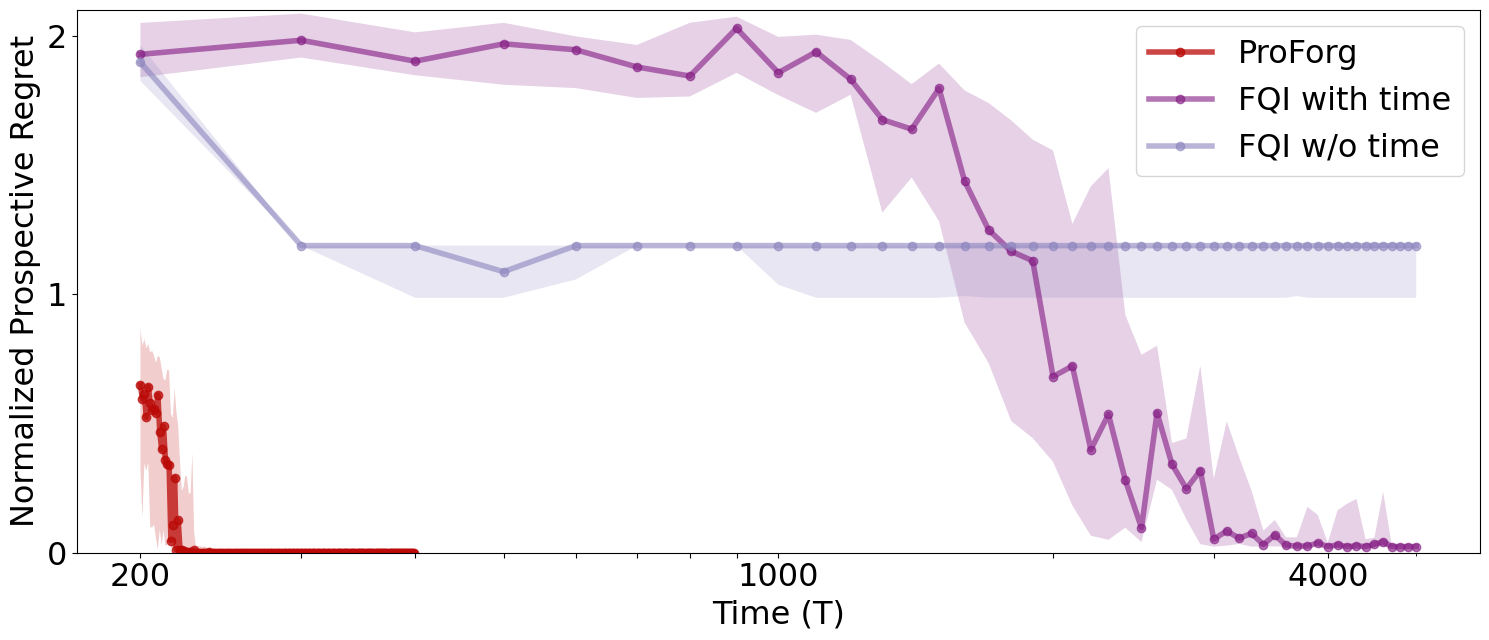

In [13]:
plt.figure(figsize=(15, 6.5))

linewidth = 4
fontsize = 28
pvafm_df_offline, pafm_df, _,pvafm_df_online = get_close_colors("OrRd", start = 0.25, delta = 0.2 , n = 4) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
rl_fqi_notime,rl_fqi_time = get_close_colors("BuPu", start=0.55, delta=0.3,n = 2)
rl_tql,_ = get_close_colors("Greens", start=0.6, delta=0.5,n = 2)
colors = {"PAFM_RF_online": pvafm_df_online,
          "PAFM_RF_offline":pvafm_df_offline,
          "PAFM_RF":pafm_df,
          "PAFM_oh_NN": pafm_nn,
          "PAFM_opt_NN":pafm_nn,
          "RL_FQI_notime":rl_fqi_notime,
          "RL_FQI_time":rl_fqi_time,
          "RL_TQL":rl_tql
          }

Ts_online = np.arange(200,400,1)
median = np.median(PREGRETS_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_DF_arr, 75, axis=0)
plt.plot(Ts_online, median[:200],color=colors["PAFM_RF_online"], lw = linewidth,marker='o',alpha = 0.75,label = 'ProForg')
plt.fill_between(Ts_online, q25[:200], q75[:200], color=colors["PAFM_RF_online"], alpha=0.20, edgecolor="none")

# median = np.median(PREGRETS_random_DF_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_random_DF_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_random_DF_arr, 75, axis=0)
# plt.plot(Ts_online, median,color=colors["PAFM_RF_offline"], lw = linewidth,marker='o',alpha = 0.3,label = 'ProForg - I - DF - offline')
# plt.fill_between(Ts_online, q25, q75, color=colors["PAFM_RF_offline"], alpha=0.20, edgecolor="none")


median = np.median(PREGRETS_RL_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_RL_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_RL_arr, 75, axis=0)
plt.plot(Ts_RL[1:], median[1:],color=colors["RL_FQI_time"], lw = linewidth,marker='o',alpha = 0.6,label = 'FQI with time')
plt.fill_between(Ts_RL[1:], q25[1:], q75[1:], color=colors["RL_FQI_time"], alpha=0.20, edgecolor="none")

median = np.median(PREGRETS_random_RL_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_random_RL_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_RL_arr, 75, axis=0)
plt.plot(Ts_RL[1:], median[1:],color=colors["RL_FQI_notime"], lw = linewidth,marker='o',alpha = 0.6,label = 'FQI w/o time')
plt.fill_between(Ts_RL[1:], q25[1:], q75[1:], color=colors["RL_FQI_notime"], alpha=0.20, edgecolor="none")
plt.xscale('log')

xticks = [i for i in np.arange(200,1000,100)]+[i for i in np.arange(1000,5000,1000)]
xticklabels = [str(v) if v in [200,1000,4000] else ""   # hide every 2nd label
               for i, v in enumerate(xticks)]
plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)
plt.ylim([0,2.1])
plt.yticks([0,1,2],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize-5)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize-5)
# plt.title('Proforg vs FQI',fontsize = fontsize)
plt.legend(fontsize = fontsize-5)
plt.savefig('ProForg_FQI.png')
plt.tight_layout()